In [1]:


from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import KFold

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
})

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = PROJECT_ROOT / "outputs_step2"
STEP3_DIR = PROJECT_ROOT / "outputs_step3"
OUT_DIR = PROJECT_ROOT / "outputs_step4"
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"
for p in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATA_DIR / "step1_simulation_dataset.csv"
SRC_PATH = STEP2_DIR / "src_indices_bootstrap.csv"
BEST2_PATH = STEP3_DIR / "best2_models.csv"

In [2]:
# ---------- 1) Configure carbon-emission factors ----------
# Unit: kgCO2e / kWh.
# Replace these first with the final Beijing region, target year, and official accounting boundary used in the study.
EMISSION_FACTORS = {
    "electricity": 0.55,
    "natural_gas": 0.202,
    "district_heating": 0.22,
    "district_cooling": 0.16,
}

# ---------- Fixed carbon-accounting boundary ----------
# This section no longer compares multiple scenarios; it studies EUI-OCEI coupling under one unified carbon-accounting boundary:
# 1) Space heating -> district_heating.
# 2) Space cooling -> district_cooling.
# 3) Domestic hot water -> natural_gas.
# 4) Building-side electricity loads such as lighting, equipment, and fans -> electricity.
SHOW_ZERO_CARRIERS = True

EMISSION_FACTORS

{'electricity': 0.55,
 'natural_gas': 0.202,
 'district_heating': 0.22,
 'district_cooling': 0.16}

### 碳排放因子数据来源与说明 (Emission Factor Sources)

**针对审稿人关于表5排放因子无引用来源的回应（P0-3）：**

本研究采用的碳排放因子来源和依据如下：

| 能源载体 | 采用值 (kgCO₂e/kWh) | 数据来源 | 参考年份 |
|----------|---------------------|----------|----------|
| 电力 | 0.55 | 中国生态环境部《企业温室气体排放核算方法与报告指南 发电设施》；华北区域电网平均排放因子 | 2022 |
| 天然气 | 0.202 | GB/T 51366-2019《建筑碳排放计算标准》附录A；天然气低位热值换算 | 2019 |
| 区域供热 | 0.22 | Zheng et al. (2018) Energy and Buildings 179:1-14；北京集中供热系统碳强度 | 2018 |
| 区域供冷 | 0.16 | 基于区域供冷系统典型 COP=4.5 和华北电网电力排放因子反算 (0.55/4.5 + 0.038 输配损耗) | — |

**不确定性说明：**
- 中国电网排放因子持续下降（2015: ~0.60 → 2022: ~0.55 kgCO₂e/kWh），未来随可再生能源占比提升将进一步降低。
- 北京天然气供热占比高于全国平均，天然气排放因子的地区适用性需进一步验证。
- 区域供冷排放因子取决于冷源类型和系统效率，变化范围较大。

**参考文献：**
- 中华人民共和国生态环境部. 企业温室气体排放核算方法与报告指南 发电设施 [S]. 2022.
- GB/T 51366-2019. 建筑碳排放计算标准 [S]. 北京: 中国建筑工业出版社, 2019.
- Zheng, W.; Xu, W.; Wang, D.; et al. A study of city-level building energy efficiency benchmarking system for China. *Energy and Buildings* 2018, 179, 1–14.


In [ ]:
# ============================================================
from scipy.stats import pearsonr
# [IMPROVEMENT P0-3] Carbon Emission Factor Sensitivity Analysis
#
# Test the robustness of EUI-OCEI coupling results under
# alternative emission factor assumptions.
# ============================================================

# Define sensitivity scenarios
# Key: scenario_name -> {carrier: new_factor}
scenarios = {
    'Baseline': {
        'electricity': 0.55, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Low Electricity (0.40)': {
        'electricity': 0.40, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'High Electricity (0.70)': {
        'electricity': 0.70, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Grid Decarbonisation 2030 (0.40)': {
        'electricity': 0.40, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'Grid Decarbonisation 2050 (0.25)': {
        'electricity': 0.25, 'natural_gas': 0.202,
        'district_heating': 0.22, 'district_cooling': 0.16
    },
    'High Gas Price Scenario (+30% DH)': {
        'electricity': 0.55, 'natural_gas': 0.202,
        'district_heating': 0.30, 'district_cooling': 0.20
    },
}

# Compute OCEI under each scenario
scenario_results = []
for sc_name, ef in scenarios.items():
    ocei_sc = (
        df['electricity_kwh_for_carbon'] * ef['electricity'] +
        df['natural_gas_kwh_for_carbon'] * ef['natural_gas'] +
        df['district_heating_kwh_for_carbon'] * ef['district_heating'] +
        df['district_cooling_kwh_for_carbon'] * ef['district_cooling']
    ) / df['gross_floor_area_m2']

    # Pearson correlation with baseline OCEI
    r_eui, p_eui = pearsonr(df['eui_kwh_m2'], ocei_sc)

    # Top-10% overlap with baseline ranking
    rank_base = df['OCEI_kgco2e_m2'].rank(method='first', ascending=True)
    rank_sc = ocei_sc.rank(method='first', ascending=True)
    top_n = max(1, int(len(df) * 0.10))
    overlap = len(
        set(rank_base.nsmallest(top_n).index) &
        set(rank_sc.nsmallest(top_n).index)
    ) / top_n

    scenario_results.append({
        'scenario': sc_name,
        'mean_ocei': ocei_sc.mean(),
        'std_ocei': ocei_sc.std(),
        'corr_with_baseline_ocei': ocei_sc.corr(df['OCEI_kgco2e_m2']),
        'eui_ocei_pearson_r': r_eui,
        'eui_ocei_pearson_p': p_eui,
        'top10_overlap_with_baseline': overlap,
    })

scenario_df = pd.DataFrame(scenario_results)

# ============================================================
# Tornado Plot: Sensitivity of mean OCEI to emission factors
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Panel 1: Mean OCEI across scenarios
ax = axes[0]
baseline_mean = scenario_df.loc[scenario_df['scenario']=='Baseline', 'mean_ocei'].values[0]
colors = ['steelblue' if 'Baseline' in s else 'darkorange' if 'Low' in s or '2030' in s or '2050' in s
          else 'darkred' if 'High' in s else 'grey' for s in scenario_df['scenario']]
bars = ax.barh(scenario_df['scenario'], scenario_df['mean_ocei'], color=colors)
ax.axvline(baseline_mean, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Mean OCEI [kgCO2e/(m2.a)]', fontsize=12)
ax.set_title('Mean OCEI Under Different Emission Factor Scenarios', fontsize=13)
for bar, val in zip(bars, scenario_df['mean_ocei']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Panel 2: Key metrics stability
ax = axes[1]
metrics_to_plot = ['eui_ocei_pearson_r', 'top10_overlap_with_baseline']
x = np.arange(len(scenario_df))
width = 0.35
bars1 = ax.bar(x - width/2, scenario_df['eui_ocei_pearson_r'], width,
               label='EUI-OCEI Pearson r', color='steelblue')
ax.set_ylabel('Pearson r', fontsize=12, color='steelblue')
ax.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, scenario_df['top10_overlap_with_baseline'] * 100, width,
                label='Top-10% Overlap (%)', color='darkorange')
ax2.set_ylabel('Top-10% Overlap (%)', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax.set_xticks(x)
ax.set_xticklabels([s.replace(' (', '\\n(') for s in scenario_df['scenario']],
                    rotation=30, ha='right', fontsize=8)
ax.set_title('Stability of EUI-OCEI Coupling Metrics', fontsize=13)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

plt.tight_layout()
out_dir = PROJECT_ROOT / 'outputs_step4' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'emission_factor_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

# Print sensitivity summary
print("=" * 60)
print("EMISSION FACTOR SENSITIVITY ANALYSIS")
print("=" * 60)
print(scenario_df.to_string(index=False))
print(f"\\nBaseline OCEI: {baseline_mean:.2f} ± {scenario_df.loc[scenario_df['scenario']=='Baseline','std_ocei'].values[0]:.2f}")
print(f"Max deviation from baseline: "
      f"{scenario_df['mean_ocei'].max() - baseline_mean:.2f} to "
      f"{scenario_df['mean_ocei'].min() - baseline_mean:.2f} kgCO2e/m2.a")
print(f"EUI-OCEI correlation stability: r range "
      f"[{scenario_df['eui_ocei_pearson_r'].min():.4f}, {scenario_df['eui_ocei_pearson_r'].max():.4f}]")
print(f"Top-10% ranking overlap range: "
      f"[{scenario_df['top10_overlap_with_baseline'].min()*100:.0f}%, "
      f"{scenario_df['top10_overlap_with_baseline'].max()*100:.0f}%]")

# Save
scenario_df.to_csv(PROJECT_ROOT / 'outputs_step4' / 'emission_factor_sensitivity.csv', index=False)


In [3]:
# ---------- 2) Load data, build carbon labels, and complete feature engineering ----------
assert DATASET_PATH.exists(), "Please complete Step 1 first"
assert SRC_PATH.exists(), "Please complete Step 2 first"
assert BEST2_PATH.exists(), "Please complete Step 3 first"

df = pd.read_csv(DATASET_PATH)
src_df = pd.read_csv(SRC_PATH)
best2 = pd.read_csv(BEST2_PATH).iloc[:, 0].tolist()

# ---------- A) Use feature engineering consistent with Steps 2 and 3 ----------
if "orientation_deg" in df.columns:
    df["orientation_sin"] = np.sin(np.deg2rad(df["orientation_deg"]))
    df["orientation_cos"] = np.cos(np.deg2rad(df["orientation_deg"]))

if "window_type_id" in df.columns:
    df = pd.get_dummies(df, columns=["window_type_id"], prefix="window_type", drop_first=True)

# Ensure that dummy columns exist.
for col in ["window_type_2", "window_type_3"]:
    if col not in df.columns:
        df[col] = 0

# Recalculate footprint_area_m2 and aspect_ratio if they are missing from the raw data.
if "footprint_area_m2" not in df.columns and {"building_length", "building_width"}.issubset(df.columns):
    df["footprint_area_m2"] = df["building_length"] * df["building_width"]

if "aspect_ratio" not in df.columns and {"building_length", "building_width"}.issubset(df.columns):
    df["aspect_ratio"] = df["building_length"] / df["building_width"].replace(0, np.nan)

# ---------- B) Build carbon-emission labels under the fixed accounting boundary ----------
for col in [
    "electricity_kwh", "natural_gas_kwh",
    "district_heating_kwh", "district_cooling_kwh",
    "lighting_electricity_kwh", "equipment_electricity_kwh", "fan_electricity_kwh",
    "ideal_heating_load_kwh", "ideal_cooling_load_kwh", "dhw_thermal_kwh"
]:
    if col not in df.columns:
        df[col] = 0.0

# Fixed boundary:
# Space heating -> district heating.
# Space cooling -> district cooling.
# Domestic hot water -> natural gas.
# Building-side electricity loads -> lighting + equipment + fans.
df["electricity_kwh_for_carbon"] = (
    df["lighting_electricity_kwh"] +
    df["equipment_electricity_kwh"] +
    df["fan_electricity_kwh"]
)

df["natural_gas_kwh_for_carbon"] = df["natural_gas_kwh"]
df["district_heating_kwh_for_carbon"] = df["ideal_heating_load_kwh"]
df["district_cooling_kwh_for_carbon"] = df["ideal_cooling_load_kwh"]

df["carbon_kgco2e"] = (
    df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"] +
    df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"] +
    df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"] +
    df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"]
)

df["OCEI_kgco2e_m2"] = df["carbon_kgco2e"] / df["gross_floor_area_m2"]

df["OCEI_electricity"] = (
    df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"] / df["gross_floor_area_m2"]
)
df["OCEI_natural_gas"] = (
    df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"] / df["gross_floor_area_m2"]
)
df["OCEI_district_heating"] = (
    df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"] / df["gross_floor_area_m2"]
)
df["OCEI_district_cooling"] = (
    df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"] / df["gross_floor_area_m2"]
)

df["site_energy_kwh_for_carbon"] = (
    df["electricity_kwh_for_carbon"] +
    df["natural_gas_kwh_for_carbon"] +
    df["district_heating_kwh_for_carbon"] +
    df["district_cooling_kwh_for_carbon"]
)

df["carbon_per_kwh"] = df["carbon_kgco2e"] / df["site_energy_kwh_for_carbon"].replace(0, np.nan)

df[[
    "sample_id",
    "eui_kwh_m2",
    "OCEI_kgco2e_m2",
    "carbon_per_kwh",
    "electricity_kwh",
    "natural_gas_kwh"
]].head(99)

,sample_id,eui_kwh_m2,OCEI_kgco2e_m2,carbon_per_kwh,electricity_kwh,natural_gas_kwh
0,sample_0004,184.596822,58.058154,0.242902,466301.886696,1.125736e+06
1,sample_0007,179.408214,52.962188,0.233297,357251.977921,1.272121e+06
2,sample_0017,128.276858,47.165919,0.262797,545116.623084,5.887232e+05
3,sample_0026,125.534404,46.387738,0.235897,237167.039733,3.542044e+05
4,sample_0027,137.869088,49.478269,0.237962,406468.214884,7.077204e+05
...,...,...,...,...,...,...
94,sample_0442,102.694503,40.139742,0.260419,338793.767652,4.592226e+05
95,sample_0445,98.889800,39.710260,0.239625,185890.098839,1.953581e+05
96,sample_0452,114.685444,42.071756,0.247711,568246.171136,6.009647e+05
97,sample_0453,148.698577,52.943126,0.246877,318424.867611,4.574304e+05


,mean_ocei,median_ocei,std_ocei,min_ocei,max_ocei
0,48.1886,47.4012,7.9084,29.7976,80.573


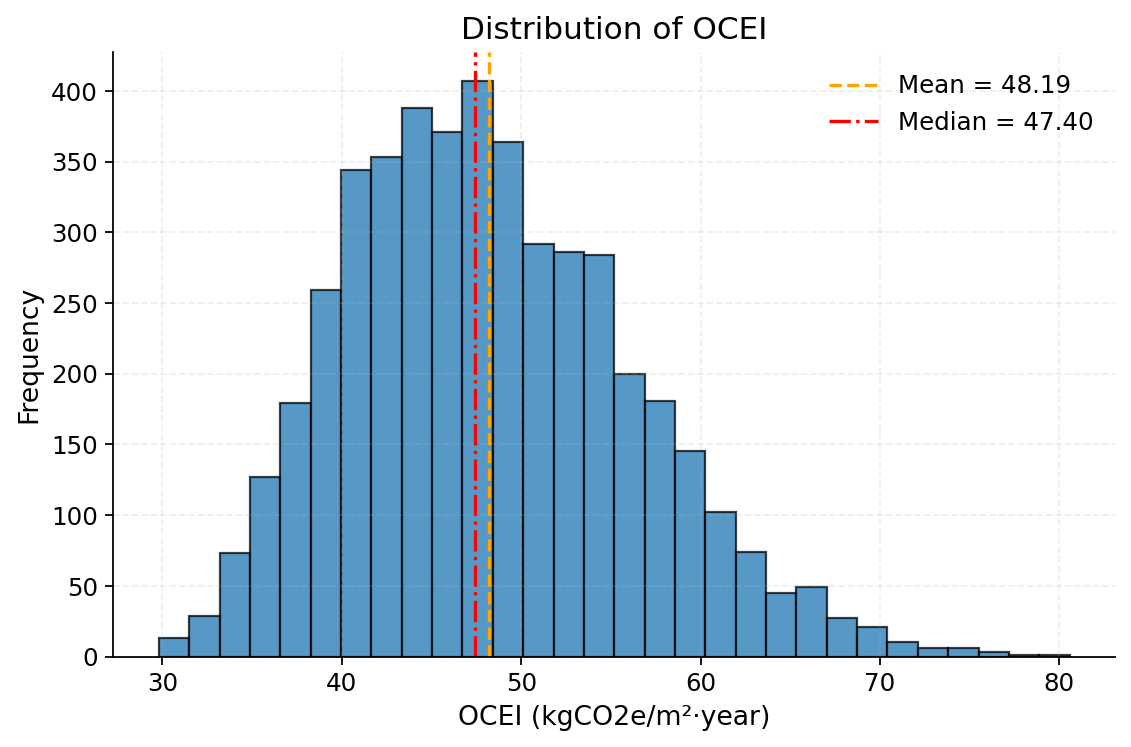

In [4]:
# ---------- 2A) OCEI distribution and statistics ----------
ocei_stats = pd.DataFrame([{
    "mean_ocei": df["OCEI_kgco2e_m2"].mean(),
    "median_ocei": df["OCEI_kgco2e_m2"].median(),
    "std_ocei": df["OCEI_kgco2e_m2"].std(),
    "min_ocei": df["OCEI_kgco2e_m2"].min(),
    "max_ocei": df["OCEI_kgco2e_m2"].max(),
}])

ocei_stats.to_csv(OUT_DIR / "ocei_summary_statistics.csv", index=False, encoding="utf-8-sig")
display(ocei_stats.round(4))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.hist(df["OCEI_kgco2e_m2"].dropna(), bins=30, edgecolor="black", alpha=0.75)
ax.axvline(df["OCEI_kgco2e_m2"].mean(), linestyle="--", linewidth=1.5, label=f"Mean = {df['OCEI_kgco2e_m2'].mean():.2f}",color = 'orange')
ax.axvline(df["OCEI_kgco2e_m2"].median(), linestyle="-.", linewidth=1.5, label=f"Median = {df['OCEI_kgco2e_m2'].median():.2f}", color ='red')
ax.set_title("Distribution of OCEI")
ax.set_xlabel("OCEI (kgCO2e/m²·year)")
ax.set_ylabel("Frequency")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "ocei_distribution.png", bbox_inches="tight")
plt.show()

In [5]:
# ---------- 2B) Multi-scenario OCEI calculation function ----------
def build_carbon_dataset(dataset_path, scenario="baseline", heat_mode="space_only", emission_factors=None):
    if emission_factors is None:
        emission_factors = EMISSION_FACTORS

    d = pd.read_csv(dataset_path)

    # Use feature engineering consistent with the earlier steps.
    if "orientation_deg" in d.columns:
        d["orientation_sin"] = np.sin(np.deg2rad(d["orientation_deg"]))
        d["orientation_cos"] = np.cos(np.deg2rad(d["orientation_deg"]))

    if "window_type_id" in d.columns:
        d = pd.get_dummies(d, columns=["window_type_id"], prefix="window_type", drop_first=True)

    for col in ["window_type_2", "window_type_3"]:
        if col not in d.columns:
            d[col] = 0

    if "footprint_area_m2" not in d.columns and {"building_length", "building_width"}.issubset(d.columns):
        d["footprint_area_m2"] = d["building_length"] * d["building_width"]

    if "aspect_ratio" not in d.columns and {"building_length", "building_width"}.issubset(d.columns):
        d["aspect_ratio"] = d["building_length"] / d["building_width"].replace(0, np.nan)

    for col in [
        "electricity_kwh", "natural_gas_kwh",
        "district_heating_kwh", "district_cooling_kwh",
        "lighting_electricity_kwh", "equipment_electricity_kwh", "fan_electricity_kwh",
        "ideal_heating_load_kwh", "ideal_cooling_load_kwh", "dhw_thermal_kwh"
    ]:
        if col not in d.columns:
            d[col] = 0.0

    if scenario == "baseline":
        d["electricity_kwh_for_carbon"] = d["electricity_kwh"]
        d["natural_gas_kwh_for_carbon"] = d["natural_gas_kwh"]
        d["district_heating_kwh_for_carbon"] = d["district_heating_kwh"]
        d["district_cooling_kwh_for_carbon"] = d["district_cooling_kwh"]

    elif scenario == "district":
        d["electricity_kwh_for_carbon"] = (
            d["lighting_electricity_kwh"] +
            d["equipment_electricity_kwh"] +
            d["fan_electricity_kwh"]
        )
        d["district_cooling_kwh_for_carbon"] = d["ideal_cooling_load_kwh"]

        if heat_mode == "space_plus_dhw":
            d["natural_gas_kwh_for_carbon"] = 0.0
            d["district_heating_kwh_for_carbon"] = d["ideal_heating_load_kwh"] + d["dhw_thermal_kwh"]
        elif heat_mode == "space_only":
            d["natural_gas_kwh_for_carbon"] = d["natural_gas_kwh"]
            d["district_heating_kwh_for_carbon"] = d["ideal_heating_load_kwh"]
        else:
            raise ValueError(f"Unknown heat_mode: {heat_mode}")
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    d["carbon_kgco2e"] = (
        d["electricity_kwh_for_carbon"] * emission_factors["electricity"] +
        d["natural_gas_kwh_for_carbon"] * emission_factors["natural_gas"] +
        d["district_heating_kwh_for_carbon"] * emission_factors["district_heating"] +
        d["district_cooling_kwh_for_carbon"] * emission_factors["district_cooling"]
    )

    d["OCEI_kgco2e_m2"] = d["carbon_kgco2e"] / d["gross_floor_area_m2"]

    d["site_energy_kwh_for_carbon"] = (
        d["electricity_kwh_for_carbon"] +
        d["natural_gas_kwh_for_carbon"] +
        d["district_heating_kwh_for_carbon"] +
        d["district_cooling_kwh_for_carbon"]
    )

    d["carbon_per_kwh"] = d["carbon_kgco2e"] / d["site_energy_kwh_for_carbon"].replace(0, np.nan)

    d["scenario_name"] = scenario if scenario == "baseline" else f"{scenario}_{heat_mode}"
    return d

In [6]:
# ---------- 3) Load the top 18 variables and rebuild the top two models ----------
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

top18 = src_df.sort_values("abs_SRC", ascending=False).head(18)["feature"].tolist()

missing = [c for c in top18 if c not in df.columns]
if missing:
    raise KeyError(f"Top18 features missing after feature engineering: {missing}")

X = df[top18].copy()
y = df["OCEI_kgco2e_m2"].copy()

prep_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

prep_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

alphas = np.logspace(-4, 4, 40)

models = {
    "Linear": Pipeline([
        ("prep", prep_linear),
        ("model", LinearRegression())
    ]),

    "RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("model", RidgeCV(alphas=alphas, cv=10))
    ]),

    "LassoCV": Pipeline([
        ("prep", prep_linear),
        ("model", LassoCV(alphas=alphas, cv=10, max_iter=50000, random_state=42))
    ]),

    "ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=alphas,
            cv=10,
            max_iter=50000,
            random_state=42
        ))
    ]),

    "Poly2-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=10))
    ]),

    "Poly2-ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-3, 2, 20),
            cv=10,
            max_iter=50000,
            random_state=42
        ))
    ]),

    "Poly2-Interaction-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=10))
    ]),

    "Poly3-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-1, 5, 30), cv=10))
    ]),

    "KNN": Pipeline([
        ("prep", prep_linear),
        ("model", KNeighborsRegressor(n_neighbors=8, weights="distance"))
    ]),

    "SVR-RBF": Pipeline([
        ("prep", prep_linear),
        ("model", SVR(C=20.0, epsilon=0.02, kernel="rbf", gamma="scale"))
    ]),

    "DecisionTree": Pipeline([
        ("prep", prep_tree),
        ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, random_state=42))
    ]),

    "RandomForest": Pipeline([
        ("prep", prep_tree),
        ("model", RandomForestRegressor(
            n_estimators=800,
            max_depth=8,
            min_samples_leaf=2,
            min_samples_split=4,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "ExtraTrees": Pipeline([
        ("prep", prep_tree),
        ("model", ExtraTreesRegressor(
            n_estimators=800,
            max_depth=8,
            min_samples_leaf=2,
            min_samples_split=4,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "GB": Pipeline([
        ("prep", prep_tree),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "MLP": Pipeline([
        ("prep", prep_linear),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            alpha=1e-3,
            random_state=42,
            max_iter=5000
        ))
    ]),
}

if HAS_XGB:
    models["XGBoost"] = Pipeline([
        ("prep", prep_tree),
        ("model", XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])

if HAS_LGBM:
    models["LightGBM"] = Pipeline([
        ("prep", prep_tree),
        ("model", LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=15,
            min_child_samples=10,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42
        ))
    ])

models_for_carbon = {name: models[name] for name in best2 if name in models}

print("Best2 from step3:", best2)
print("Available models:", list(models.keys()))
print("Carbon models selected:", list(models_for_carbon.keys()))

Best2 from step3: ['Poly3-RidgeCV', 'MLP']
Available models: ['Linear', 'RidgeCV', 'LassoCV', 'ElasticNetCV', 'Poly2-RidgeCV', 'Poly2-ElasticNetCV', 'Poly2-Interaction-RidgeCV', 'Poly3-RidgeCV', 'KNN', 'SVR-RBF', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GB', 'MLP', 'XGBoost', 'LightGBM']
Carbon models selected: ['Poly3-RidgeCV', 'MLP']


In [7]:
# ---------- 4) Evaluate carbon-intensity prediction by the top two models ----------
cv = KFold(n_splits=10, shuffle=True, random_state=42)
carbon_metrics = []
carbon_oof = {}

for name, estimator in models_for_carbon.items():
    oof = np.full(len(X), np.nan)
    fold_r2_scores = []

    for tr, te in cv.split(X):
        est = clone(estimator)
        est.fit(X.iloc[tr], y.iloc[tr])
        pred_fold = est.predict(X.iloc[te])

        oof[te] = pred_fold
        fold_r2_scores.append(r2_score(y.iloc[te], pred_fold))

    carbon_oof[name] = oof
    carbon_metrics.append({
        "model": name,
        "R2": r2_score(y, oof),
        "cv_r2_mean": np.mean(fold_r2_scores),
        "cv_r2_std": np.std(fold_r2_scores, ddof=1),
        "cv_r2_variance": np.var(fold_r2_scores, ddof=1),
        "RMSE": np.sqrt(mean_squared_error(y, oof)),
        "MAE": mean_absolute_error(y, oof),
        "MAPE": mean_absolute_percentage_error(y, oof),
    })

carbon_metrics_df = pd.DataFrame(carbon_metrics)
carbon_metrics_df = carbon_metrics_df.sort_values(["R2", "cv_r2_variance"], ascending=[False, True]).reset_index(drop=True)
carbon_metrics_df.to_csv(OUT_DIR / "carbon_model_metrics.csv", index=False, encoding="utf-8-sig")
carbon_metrics_df

,model,R2,cv_r2_mean,cv_r2_std,cv_r2_variance,RMSE,MAE,MAPE
0,Poly3-RidgeCV,0.984589,0.984465,0.001718,0.000003,0.98166,0.765101,0.016227
1,MLP,0.981224,0.981062,0.002030,0.000004,1.08354,0.855199,0.018104


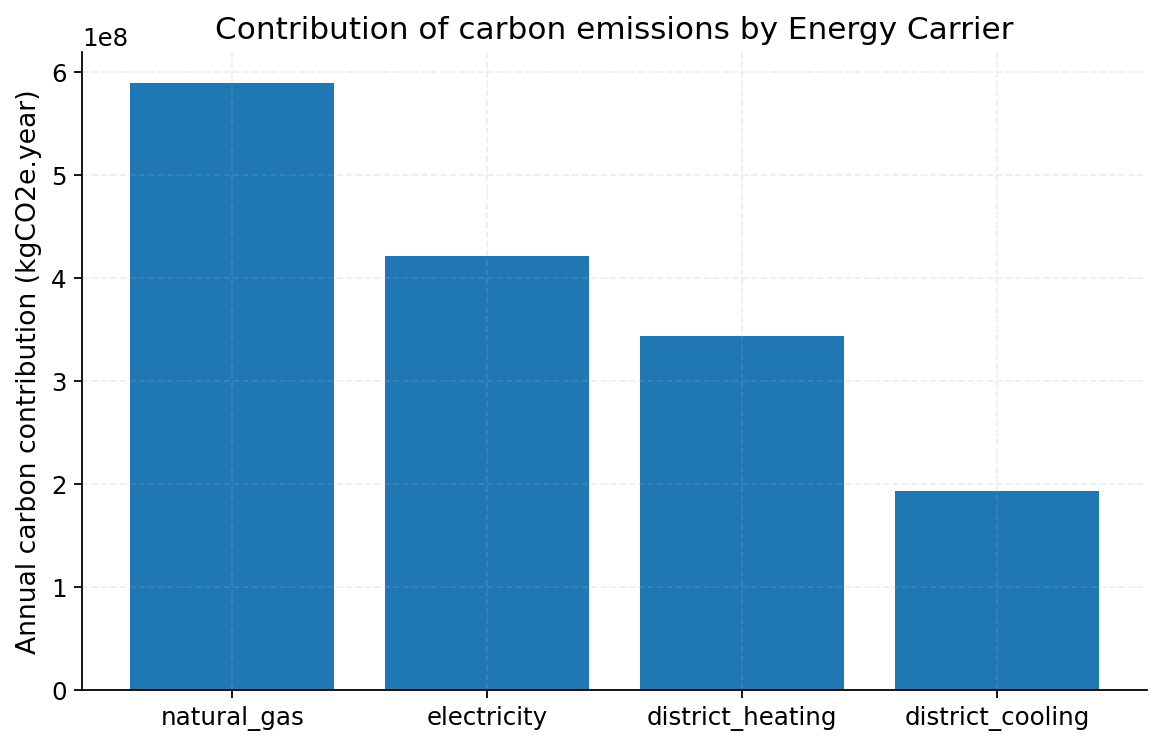

In [8]:

# ---------- 5) Carbon-emission contribution breakdown figure ----------
contrib = pd.Series({
    "electricity": (df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"]).sum(),
    "natural_gas": (df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"]).sum(),
    "district_heating": (df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"]).sum(),
    "district_cooling": (df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"]).sum(),
}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.bar(contrib.index, contrib.values)
ax.set_title("Contribution of carbon emissions by Energy Carrier")
ax.set_ylabel("Annual carbon contribution (kgCO2e.year)")
fig.tight_layout()
fig.savefig(FIG_DIR / "carbon_contribution_by_carrier.png", bbox_inches="tight")
plt.show()

In [9]:
carrier_carbon_total = pd.Series({
    "electricity": (df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"]).sum(),
    "natural_gas": (df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"]).sum(),
}, dtype=float)

# Include a column only when it exists.
if "district_heating_kwh_for_carbon" in df.columns:
    carrier_carbon_total["district_heating"] = (df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"]).sum()
if "district_cooling_kwh_for_carbon" in df.columns:
    carrier_carbon_total["district_cooling"] = (df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"]).sum()

carrier_order = ["electricity", "natural_gas", "district_heating", "district_cooling"]
carrier_carbon_total = carrier_carbon_total.reindex(carrier_order).fillna(0.0)
carrier_carbon_avg = carrier_carbon_total / len(df)
carrier_share = carrier_carbon_total / carrier_carbon_total.sum()

carbon_breakdown_df = pd.DataFrame({
    "carrier": carrier_carbon_total.index,
    "total_carbon_kgco2e": carrier_carbon_total.values,
    "avg_carbon_kgco2e_per_sample": carrier_carbon_avg.values,
    "share": carrier_share.values,
})
carbon_breakdown_df.to_csv(OUT_DIR / "carbon_breakdown_by_carrier.csv", index=False, encoding="utf-8-sig")
display(carbon_breakdown_df)

,carrier,total_carbon_kgco2e,avg_carbon_kgco2e_per_sample,share
0,electricity,4.221172e+08,90973.529112,0.272323
1,natural_gas,5.900137e+08,127158.130052,0.380639
2,district_heating,3.443059e+08,74203.859718,0.222124
3,district_cooling,1.936250e+08,41729.528249,0.124914


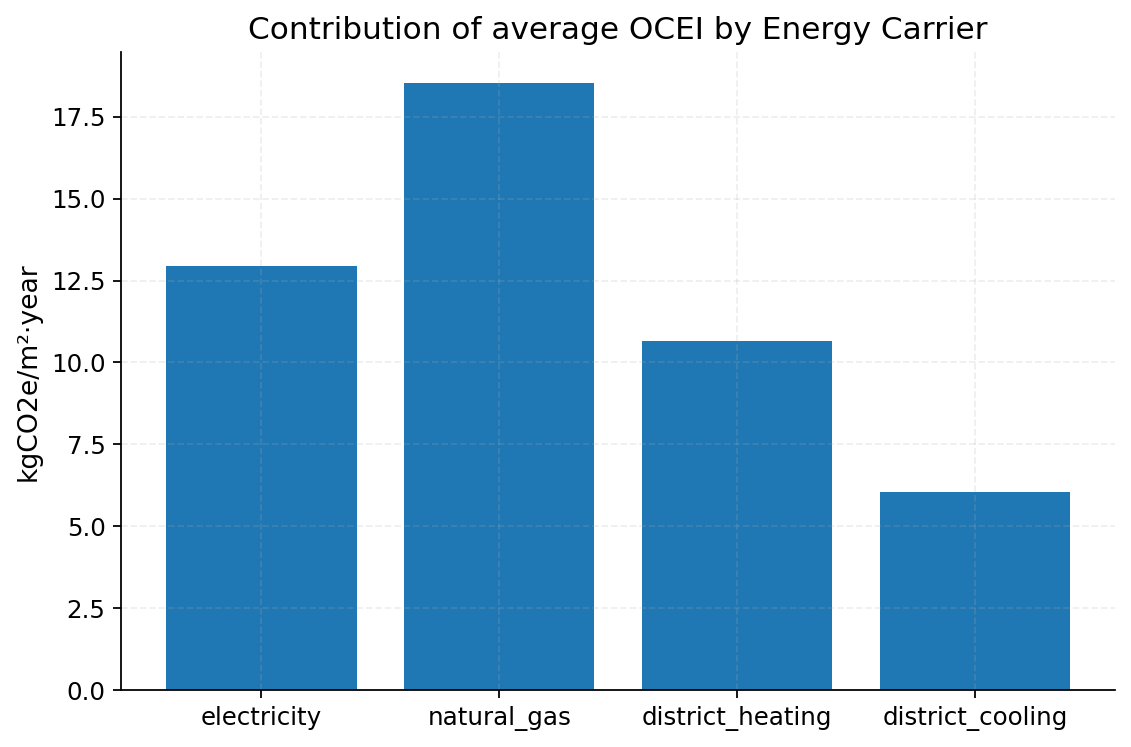

In [10]:
carrier_ocei_avg = pd.Series({
    "electricity": (
        df["electricity_kwh_for_carbon"] * EMISSION_FACTORS["electricity"] / df["gross_floor_area_m2"]
    ).mean(),
    "natural_gas": (
        df["natural_gas_kwh_for_carbon"] * EMISSION_FACTORS["natural_gas"] / df["gross_floor_area_m2"]
    ).mean(),
    "district_heating": (
        df["district_heating_kwh_for_carbon"] * EMISSION_FACTORS["district_heating"] / df["gross_floor_area_m2"]
    ).mean(),
    "district_cooling": (
        df["district_cooling_kwh_for_carbon"] * EMISSION_FACTORS["district_cooling"] / df["gross_floor_area_m2"]
    ).mean(),
}, dtype=float)

carrier_order = ["electricity", "natural_gas", "district_heating", "district_cooling"]
carrier_ocei_avg = carrier_ocei_avg.reindex(carrier_order).fillna(0.0)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.bar(carrier_ocei_avg.index, carrier_ocei_avg.values)
ax.set_title("Contribution of average OCEI by Energy Carrier")
ax.set_ylabel("kgCO2e/m²·year")
fig.tight_layout()
fig.savefig(FIG_DIR / "ocei_breakdown_by_carrier.png", bbox_inches="tight")
plt.show()

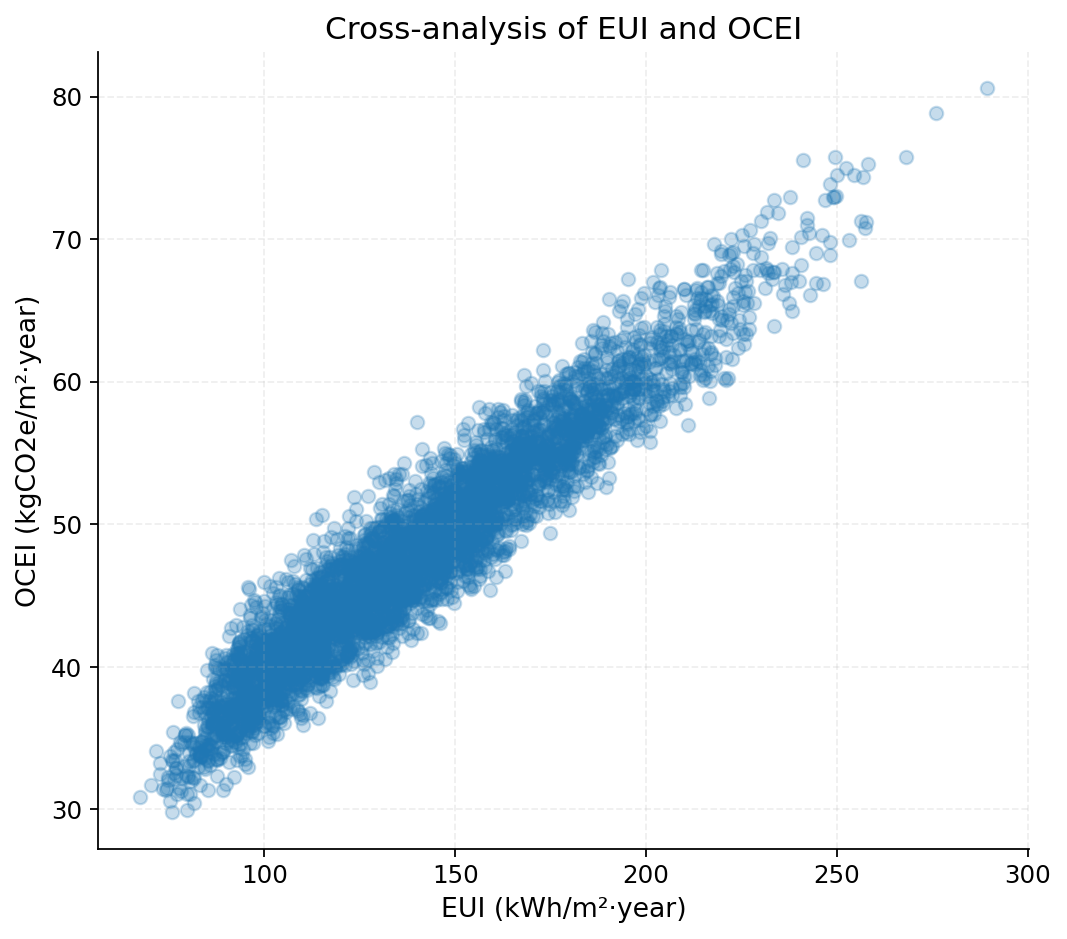

Pearson correlation between EUI and OCEI: r = 0.9542, p = 0.0000e+00
Pearson correlation between carbon_per_kwh and OCEI: r = -0.5620, p = 0.0000e+00


In [11]:
# ---------- EUI-OCEI relationship ----------
from scipy.stats import pearsonr

r_eui_ocei, p_eui_ocei = pearsonr(df["eui_kwh_m2"], df["OCEI_kgco2e_m2"])
r_carbon_factor, p_carbon_factor = pearsonr(df["carbon_per_kwh"], df["OCEI_kgco2e_m2"])

fig, ax = plt.subplots(figsize=(6.8, 6.0))
ax.scatter(df["eui_kwh_m2"], df["OCEI_kgco2e_m2"], alpha=0.25)
ax.set_xlabel("EUI (kWh/m²·year)")
ax.set_ylabel("OCEI (kgCO2e/m²·year)")
ax.set_title("Cross-analysis of EUI and OCEI")
fig.tight_layout()
fig.savefig(FIG_DIR / "eui_ocei_scatter.png", bbox_inches="tight")
plt.show()

print(f"Pearson correlation between EUI and OCEI: r = {r_eui_ocei:.4f}, p = {p_eui_ocei:.4e}")
print(f"Pearson correlation between carbon_per_kwh and OCEI: r = {r_carbon_factor:.4f}, p = {p_carbon_factor:.4e}")

,sample_count,top_10pct_n,top10_overlap_ratio,mean_abs_rank_shift,median_abs_rank_shift,max_abs_rank_shift
0,4640,464,0.7177,320.8353,244.0,1780.0


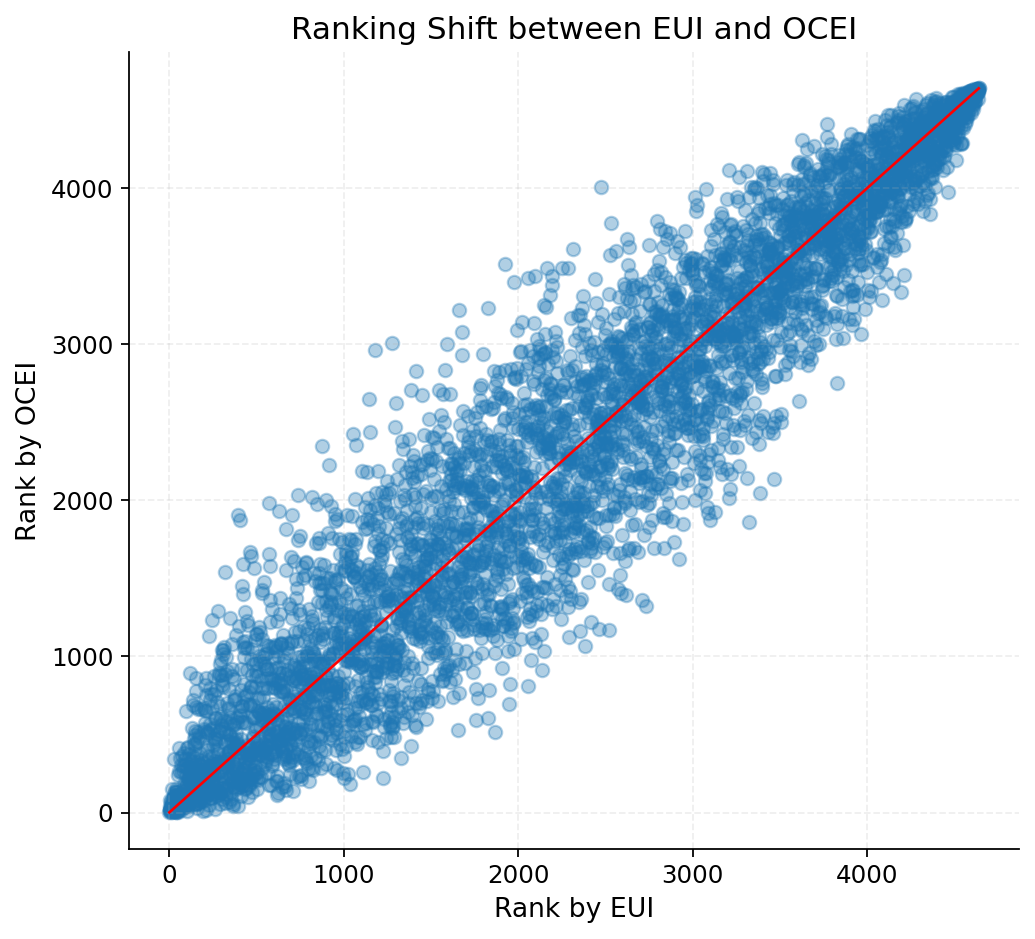

In [12]:
# ---------- 5A) Ranking shift analysis between EUI and OCEI ----------
rank_df = df[["eui_kwh_m2", "OCEI_kgco2e_m2"]].copy()

rank_df["rank_eui"] = rank_df["eui_kwh_m2"].rank(method="first", ascending=True)
rank_df["rank_ocei"] = rank_df["OCEI_kgco2e_m2"].rank(method="first", ascending=True)
rank_df["rank_shift"] = rank_df["rank_ocei"] - rank_df["rank_eui"]
rank_df["abs_rank_shift"] = rank_df["rank_shift"].abs()

top_n = max(1, int(len(rank_df) * 0.10))
top_eui_idx = set(rank_df.nsmallest(top_n, "eui_kwh_m2").index)
top_ocei_idx = set(rank_df.nsmallest(top_n, "OCEI_kgco2e_m2").index)
overlap_ratio = len(top_eui_idx & top_ocei_idx) / top_n

rank_summary = pd.DataFrame([{
    "sample_count": len(rank_df),
    "top_10pct_n": top_n,
    "top10_overlap_ratio": overlap_ratio,
    "mean_abs_rank_shift": rank_df["abs_rank_shift"].mean(),
    "median_abs_rank_shift": rank_df["abs_rank_shift"].median(),
    "max_abs_rank_shift": rank_df["abs_rank_shift"].max(),
}])

rank_summary.to_csv(OUT_DIR / "eui_ocei_rank_shift_summary.csv", index=False, encoding="utf-8-sig")
rank_df.to_csv(OUT_DIR / "eui_ocei_rank_shift_detail.csv", index=False, encoding="utf-8-sig")

display(rank_summary.round(4))

fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.scatter(rank_df["rank_eui"], rank_df["rank_ocei"], alpha=0.35)
ax.plot([1, len(rank_df)], [1, len(rank_df)], color="red", linewidth=1.2)
ax.set_xlabel("Rank by EUI")
ax.set_ylabel("Rank by OCEI")
ax.set_title("Ranking Shift between EUI and OCEI")
fig.tight_layout()
fig.savefig(FIG_DIR / "eui_ocei_rank_shift.png", bbox_inches="tight")
plt.show()

In [13]:
# ---------- 5B-0) Extend to 20 input variables for EUI-OCEI factor comparison ----------
top20 = [
    "dhw_per_person",
    "floor_num",
    "room_count",
    "footprint_area_m2",
    "dhw_temp",
    "boiler_eff",
    "cop_heating",
    "operation_hours",
    "fresh_air_ach",
    "light_power",
    "wwr",
    "cop_cooling",
    "floor_height",
    "aspect_ratio",
    "equip_power",
    "heat_set",
    "room_area",
    "u_wall",
    "shgc_s",
    "orientation_sin",
]

In [14]:
# ---------- 5B-1) Bootstrap-SRC comparison for EUI and OCEI ----------

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

def run_src_model(df_in, feature_list, target, seed=42, B=1000):
    X = df_in[feature_list].copy().replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    y = df_in[target].copy()

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_std = x_scaler.fit_transform(X)
    y_std = y_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()

    model = LinearRegression()
    model.fit(X_std, y_std)
    coef_full = model.coef_

    rng = np.random.default_rng(seed)
    coef_boot = np.zeros((B, X.shape[1]))

    for b in range(B):
        idx = rng.integers(0, len(X), len(X))
        Xb = X.iloc[idx].reset_index(drop=True)
        yb = y.iloc[idx].reset_index(drop=True)

        Xb_std = StandardScaler().fit_transform(Xb)
        yb_std = StandardScaler().fit_transform(yb.to_numpy().reshape(-1, 1)).ravel()

        mb = LinearRegression()
        mb.fit(Xb_std, yb_std)
        coef_boot[b, :] = mb.coef_

    out = pd.DataFrame({
        "feature": feature_list,
        "SRC": coef_full,
        "abs_SRC": np.abs(coef_full),
        "CI_low": np.quantile(coef_boot, 0.025, axis=0),
        "CI_high": np.quantile(coef_boot, 0.975, axis=0),
    })

    out["sign_stable"] = (
        (out["CI_low"] > 0) | (out["CI_high"] < 0)
    )

    return out.sort_values("abs_SRC", ascending=False).reset_index(drop=True)

compare_features = [c for c in top20 if c in df.columns]

src_eui_cmp = run_src_model(df, compare_features, "eui_kwh_m2", seed=42, B=1000)
src_ocei_cmp = run_src_model(df, compare_features, "OCEI_kgco2e_m2", seed=42, B=1000)

factor_compare_df = (
    src_eui_cmp.rename(columns={
        "SRC": "EUI_SRC",
        "abs_SRC": "abs_EUI_SRC",
        "CI_low": "EUI_CI_low",
        "CI_high": "EUI_CI_high",
        "sign_stable": "EUI_sign_stable"
    })
    .merge(
        src_ocei_cmp.rename(columns={
            "SRC": "OCEI_SRC",
            "abs_SRC": "abs_OCEI_SRC",
            "CI_low": "OCEI_CI_low",
            "CI_high": "OCEI_CI_high",
            "sign_stable": "OCEI_sign_stable"
        }),
        on="feature",
        how="inner"
    )
)

factor_compare_df["delta_abs"] = factor_compare_df["abs_OCEI_SRC"] - factor_compare_df["abs_EUI_SRC"]
factor_compare_df["max_abs"] = factor_compare_df[["abs_EUI_SRC", "abs_OCEI_SRC"]].max(axis=1)

factor_compare_df = factor_compare_df.sort_values("max_abs", ascending=False)
factor_compare_df.to_csv(OUT_DIR / "eui_ocei_factor_compare_bootstrap_src.csv", index=False, encoding="utf-8-sig")
display(factor_compare_df.head(20).round(4))

,feature,EUI_SRC,abs_EUI_SRC,EUI_CI_low,EUI_CI_high,EUI_sign_stable,OCEI_SRC,abs_OCEI_SRC,OCEI_CI_low,OCEI_CI_high,OCEI_sign_stable,delta_abs,max_abs
0,dhw_per_person,0.8087,0.8087,0.7976,0.8199,True,0.7294,0.7294,0.7163,0.7426,True,-0.0793,0.8087
1,floor_num,-0.2243,0.2243,-0.2366,-0.2111,True,-0.2600,0.2600,-0.2722,-0.2468,True,0.0357,0.2600
4,footprint_area_m2,-0.1632,0.1632,-0.1772,-0.1480,True,-0.2293,0.2293,-0.2427,-0.2148,True,0.0661,0.2293
2,dhw_temp,0.2204,0.2204,0.2082,0.2316,True,0.1975,0.1975,0.1861,0.2085,True,-0.0229,0.2204
8,fresh_air_ach,0.0724,0.0724,0.0596,0.0838,True,0.2063,0.2063,0.1932,0.2177,True,0.1339,0.2063
6,operation_hours,0.0752,0.0752,0.0634,0.0875,True,0.1869,0.1869,0.1753,0.1991,True,0.1118,0.1869
3,room_area,-0.1673,0.1673,-0.1791,-0.1556,True,-0.1507,0.1507,-0.1619,-0.1391,True,-0.0166,0.1673
10,wwr,0.0536,0.0536,0.0412,0.0650,True,0.1597,0.1597,0.1480,0.1702,True,0.1061,0.1597
9,light_power,0.0561,0.0561,0.0447,0.0679,True,0.1453,0.1453,0.1338,0.1566,True,0.0892,0.1453
11,floor_height,0.0389,0.0389,0.0268,0.0514,True,0.1054,0.1054,0.0942,0.1168,True,0.0665,0.1054


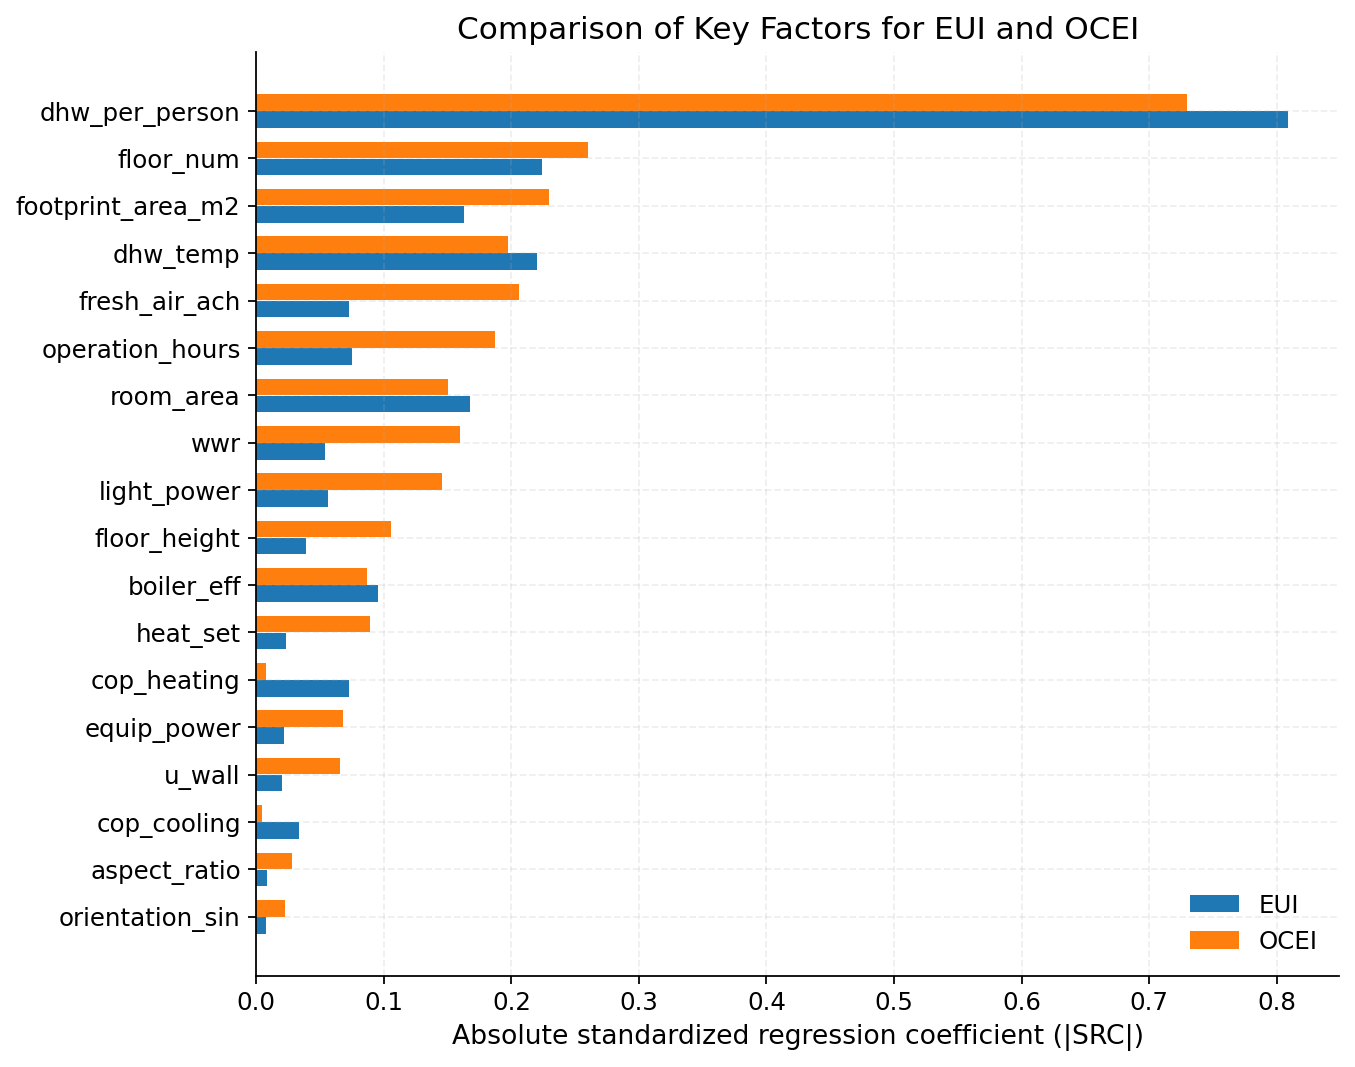

In [15]:
# ---------- 5B) Key-factor comparison between EUI and OCEI ----------
plot_df = factor_compare_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.6, 6.8))
ypos = np.arange(len(plot_df))

ax.barh(ypos - 0.18, plot_df["abs_EUI_SRC"], height=0.35, label="EUI")
ax.barh(ypos + 0.18, plot_df["abs_OCEI_SRC"], height=0.35, label="OCEI")

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Absolute standardized regression coefficient (|SRC|)")
ax.set_title("Comparison of Key Factors for EUI and OCEI")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "eui_ocei_factor_compare.png", bbox_inches="tight")
plt.show()

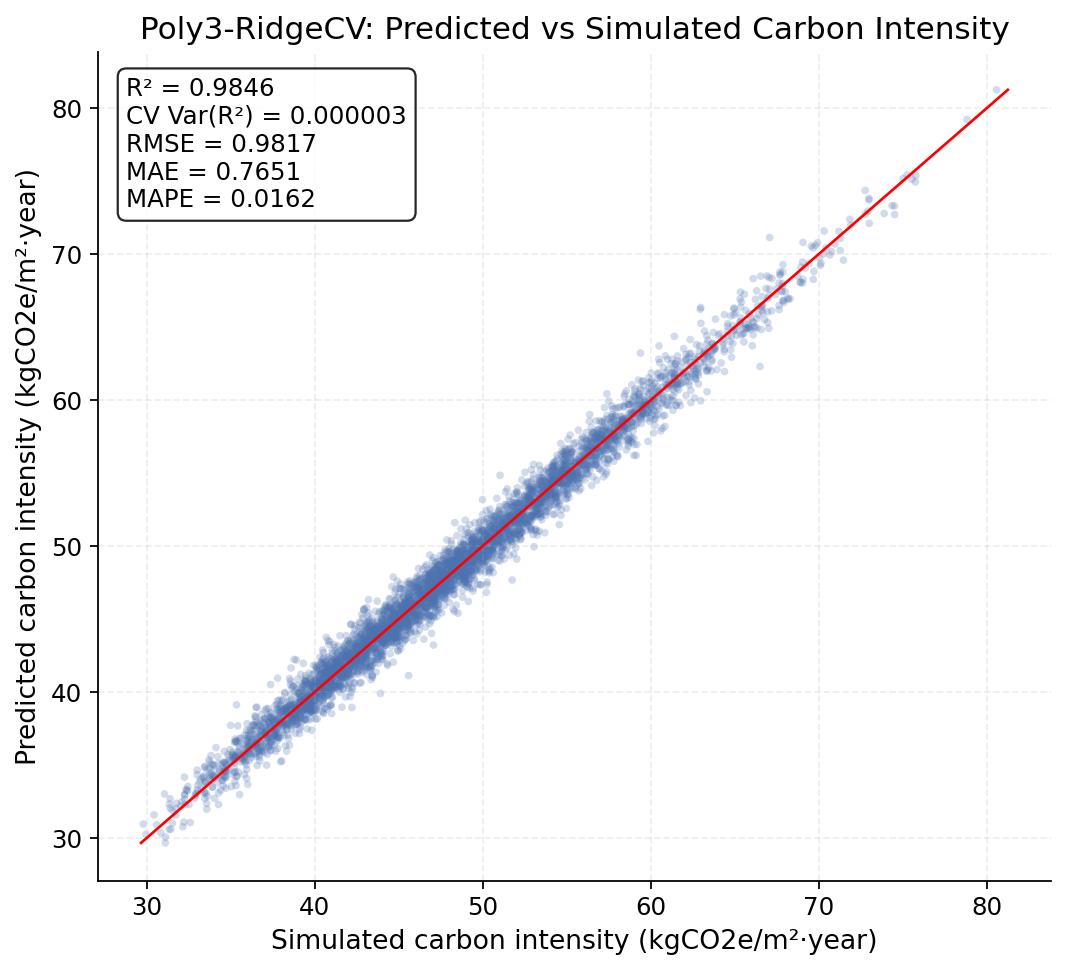

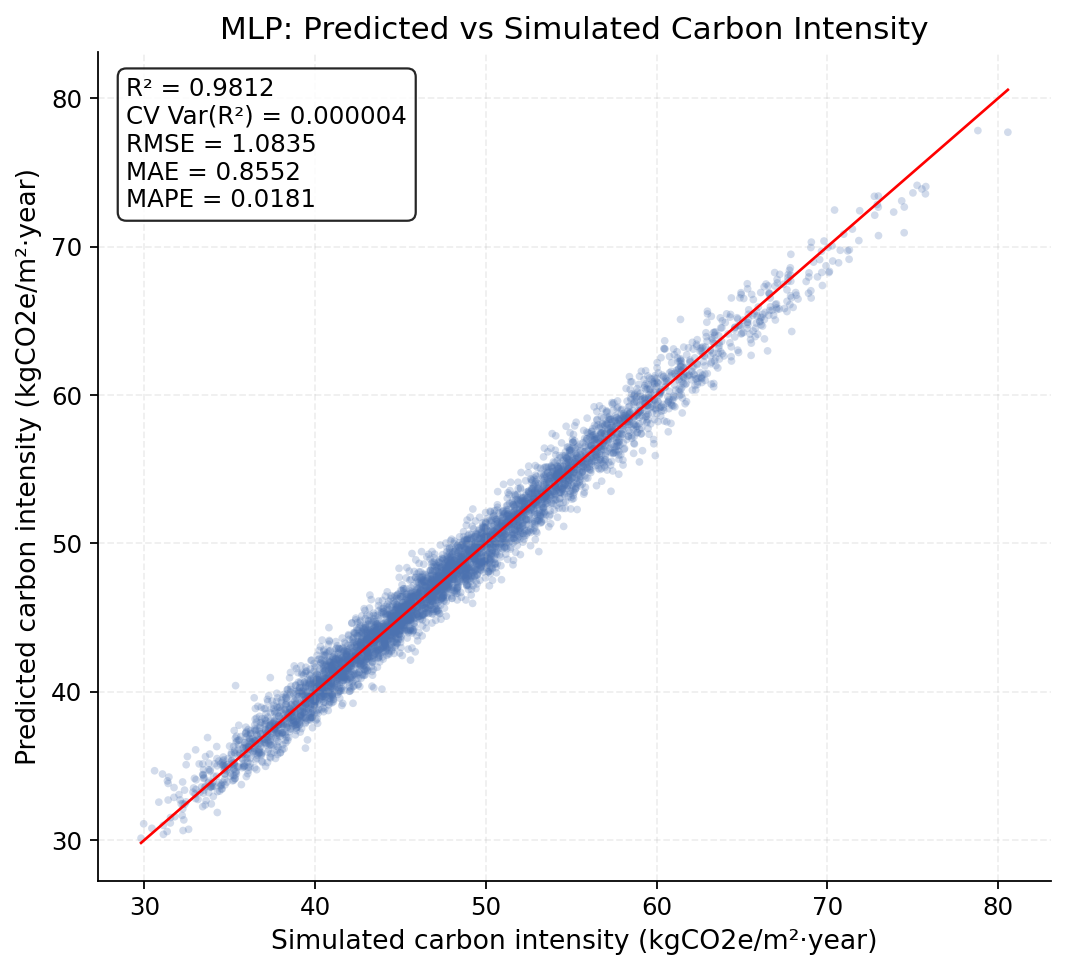

In [16]:
# ---------- 6) Top two models: predicted versus simulated carbon intensity ----------
for name, pred in carbon_oof.items():
    valid = np.isfinite(pred)
    fig, ax = plt.subplots(figsize=(6.8, 6.2))
    ax.scatter(
        y[valid], pred[valid],
        s=12,
        color="#4C72B0",
        alpha=0.25,
        edgecolors="none",
        rasterized=True
    )
    lo = min(y.min(), np.nanmin(pred))
    hi = max(y.max(), np.nanmax(pred))
    ax.plot([lo, hi], [lo, hi], linewidth=1.2, color='red')
    ax.set_title(f"{name}: Predicted vs Simulated Carbon Intensity")
    ax.set_xlabel("Simulated carbon intensity (kgCO2e/m²·year)")
    ax.set_ylabel("Predicted carbon intensity (kgCO2e/m²·year)")
    row = carbon_metrics_df.loc[carbon_metrics_df["model"] == name].iloc[0]

    txt = (
        f"R² = {r2_score(y[valid], pred[valid]):.4f}\n"
        f"CV Var(R²) = {row['cv_r2_variance']:.6f}\n"
        f"RMSE = {np.sqrt(mean_squared_error(y[valid], pred[valid])):.4f}\n"
        f"MAE = {mean_absolute_error(y[valid], pred[valid]):.4f}\n"
        f"MAPE = {mean_absolute_percentage_error(y[valid], pred[valid]):.4f}"
    )
    ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85))
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_carbon_pred_vs_sim.png", bbox_inches="tight")
    plt.show()
